### Student Information
Name: 郭揉香

Student ID: 313700031

GitHub ID: Kuo-Jou-Hsiang

---

### Instructions

### First Phase Submission

1. First: do the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) that considered as **phase 1 (from exercise 1 to exercise 15)**. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: follow the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** up **until phase 1**. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    -  Use [the new dataset](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/newdataset/Reddit-stock-sentiment.csv). The dataset contains a 16 columns including 'text' and 'label', with the sentiment labels being: 1.0 is positive, 0.0 is neutral and -1.0 is negative. You can simplify the dataset and use only the columns that you think are necessary. 
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.
    - Use this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output.


3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 10% of your grade.__
    - Generate meaningful **new data visualizations**. Refer to online resources and the Data Mining textbook for inspiration and ideas. 
    


4. Fourth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__

You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (September 28th 11:59 pm, Sunday)__. 

### Second Phase Submission 

**You can keep the answer for phase 1 for easier running and update the phase 2 on the same page.**

1. First: Continue doing the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) for **phase 2, starting from Finding frequent patterns**. Use the same master(.ipynb) file. Answer from phase 1 will not be considered at this stage. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: Continue from first phase and do the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** for phase 2, starting from Finding frequent pattern. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    - Continue using this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output. Use the same new dataset as in phase 1.
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.

3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 20% of your grade.__
    - Use this file to answer.
    - Generate **TF-IDF features** from the tokens of each text. This will generating a document matrix, however, the weights will be computed differently (using the TF-IDF value of each word per document as opposed to the word frequency).  Refer to this Scikit-learn [guide](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) .
    - Implement a simple **Naive Bayes classifier** that automatically classifies the records into their categories. Use both the TF-IDF features and word frequency features to build two seperate classifiers. Note that for the TF-IDF features you might need to use other type of NB classifier different than the one in the Master Notebook. Comment on the differences and when using augmentation with feature pattern.  Refer to this [article](https://hub.packtpub.com/implementing-3-naive-bayes-classifiers-in-scikit-learn/).


4. Fourth: In the lab, we applied each step really quickly just to illustrate how to work with your dataset. There are somethings that are not ideal or the most efficient/meaningful. Each dataset can be handled differently as well. What are those inefficent parts you noticed? How can you improve the Data preprocessing for these specific datasets? __This part is worth 10% of your grade.__


5. Fifth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__


You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (October 19th 11:59 pm, Sunday)__. 

# Phase 1

In [1]:
### Begin Assignment Here
import pandas as pd
import numpy as np
import nltk
nltk.download('punkt') # download the NLTK datasets
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
import plotly as py
import math
# If you get "ModuleNotFoundError: No module named 'PAMI'"
# run the following in a new Jupyter cell:
# !pip3 install PAMI
import PAMI
import umap

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/kuojouhsiang/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [3]:
df = pd.read_csv("/Users/kuojouhsiang/Documents/DM2025Labs./DM2025-Lab1-Exercise/newdataset/Reddit-stock-sentiment.csv")
df.head(10)

,type,datetime,post_id,subreddit,title,author,url,upvotes,downvotes,upvote_ratio,text,subjectivity,polarity,sentiment,entities,label
0,comment,2025-04-11 17:29:56,mmli62w,wallstreetbets,Retardation is on the menu boys! WSB is so back,StickyTip420,https://i.redd.it/0yq2ftren8ue1.jpeg,0,NaN,NaN,Calls on retards,1.000000,-0.900000,-1.0,[],-1.0
1,comment,2025-04-12 1:12:19,mmnu7v9,wallstreetbets,Retail giant TARGET has now declined for 10 co...,Comfortable-Dog-8437,https://i.redd.it/7tl6puv9waue1.jpeg,-15,NaN,NaN,Stunt as in like why did they even make a big ...,0.177778,0.083333,1.0,"['Stunt', 'company', 'deal', 'place']",0.0
2,comment,2025-04-10 15:09:41,mmeevio,StockMarket,How do you feel about a sitting president maki...,Btankersly66,https://apnews.com/article/trump-truth-social-...,1,NaN,NaN,Seeing lots of red in the ticker.,0.000000,0.000000,0.0,['ticker'],0.0
3,post,2023-08-30 17:12:55,165kllm,stockstobuytoday,Who knows more? $VMAR,emiljenfn,https://www.reddit.com/r/stockstobuytoday/comm...,30,0.0,0.98,Vision Marine Technologies Inc. is rewriting t...,0.646970,0.216383,1.0,"['watercraft', 'skill', 'power', ']', 'feat', ...",1.0
4,comment,2025-04-11 14:48:05,mmkl6bw,StockMarket,The Trump administration is begging Xi Jinping...,Just-Big6411,https://edition.cnn.com/2025/04/10/politics/tr...,1,NaN,NaN,He didn’t say thank you.,0.000000,0.000000,0.0,[],-1.0
5,comment,2025-04-12 2:19:03,mmo4k9g,wallstreetbets,Weekend Discussion Thread for the Weekend of A...,PolarNimbus,https://www.reddit.com/r/wallstreetbets/commen...,16,NaN,NaN,"Hoping to ejaculate in wet warm puss tonight, ...",0.500000,0.250000,1.0,"['tonight', 'puss']",0.0
6,comment,2025-04-11 12:37:23,mmjx7vz,stocks,Is the market in complete denial right now?,stoniey84,https://www.reddit.com/r/stocks/comments/1jwo1...,5,NaN,NaN,Trump will respond to china increasing their t...,0.380000,-0.108333,-1.0,"['JPow', 'Jerome', 'i', 'reporting', 'Trump', ...",-1.0
7,comment,2025-04-11 17:28:50,mmlhxwc,wallstreetbets,Retardation is on the menu boys! WSB is so back,OSRSkarma,https://i.redd.it/0yq2ftren8ue1.jpeg,-3,NaN,NaN,Confirmed not a trap. Its been like this for p...,0.700000,0.050000,1.0,"['Confirmed', 'mouth', 'word', 'trap']",0.0
8,comment,2021-02-01 15:36:32,gllyi5z,stocks,"It's fucking awful seeing the ""Silver"" misinfo...",Blondbox,https://www.reddit.com/r/stocks/comments/la34b...,1,NaN,NaN,Am I the only one seeing the cup & handle brea...,0.491818,0.057045,1.0,"['cup', 'Day', 'handle', 'pivot', 'Green', 'tr...",1.0
9,comment,2021-12-31 16:29:49,hqp3kt4,stockstobuytoday,Any cheap stocks under $10?,Zumuru,https://www.reddit.com/r/stockstobuytoday/comm...,2,NaN,NaN,HLGN is $10. Hurry and catch it now before it ...,0.000000,0.000000,0.0,"['HLGN', 'Hurry', 'moon']",1.0


## 1.Data Preparation + Data Transformation

In [4]:
#保留要的欄位
df = df[['text','label']]
print(df.head(10))
print(len(df))

                                                text  label
0                                   Calls on retards   -1.0
1  Stunt as in like why did they even make a big ...    0.0
2                  Seeing lots of red in the ticker.    0.0
3  Vision Marine Technologies Inc. is rewriting t...    1.0
4                           He didn’t say thank you.   -1.0
5  Hoping to ejaculate in wet warm puss tonight, ...    0.0
6  Trump will respond to china increasing their t...   -1.0
7  Confirmed not a trap. Its been like this for p...    0.0
8  Am I the only one seeing the cup & handle brea...    1.0
9  HLGN is $10. Hurry and catch it now before it ...    1.0
847


In [ ]:
#分測試集/訓練集，按標籤比例抽樣維持比例一致
from sklearn.model_selection import train_test_split
X = df['text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42, stratify=df['label'])
train_df = pd.DataFrame({'text': X_train, 'label': y_train})
test_df = pd.DataFrame({'text': X_test, 'label': y_test})

In [6]:
label_names = {
    -1.0: "negative",
     0.0: "neutral",
     1.0: "positive"
}

In [33]:
train_df['label_name'] = train_df['label'].map(label_names)
test_df['label_name'] = test_df['label'].map(label_names)

In [36]:
train_df["text"][5:10].tolist()

['I think we are past the numbers. Just assume folks world wide are now looking for another safe place to store their money.\n\nWe used to be the place. That is over.\n\nHell I am in the US and I am looking for a safer place to store my money.\n\nWe are in uncharted waters here and we have an economy that was already shaky to begin with.\n\nFar too many Americans are woefully unaware of how big the world is or how much we actually depend on them. \n\nLots of hard lessons to be learned going forward.\n\nTo sell bonds and treasuries we need people to believe their money is safe if they buy them. That idea is rapidly exiting stage right.\n\nI could be wrong but I think those rates are  screaming at us that we are going down rapidly as a trusted partner.',
 'it was amc day today. fsr after hrs',
 "Trump grossly miscalculated if he thought he could extort China. Even if you could someone prove the hurt to China will be much worse, and the reality is China has a lot of problems right now, th

In [40]:
list(label_names.values())

['negative', 'neutral', 'positive']

In [42]:
len(train_df.text)

677

In [48]:
train_df = train_df.reset_index(drop=True)
print("\n".join(train_df.loc[9, "text"].split("\n")))

Trump will respond to china increasing their tariffs. Trump is looking to fire Jerome Powell. Earnings reporting is starting. I personally think the next few weeks are going to be brutal.... if all companies adjust downwards and JPow is fired, i can see it going down A LOT and very quickly even


In [47]:
print("\n".join(train_df.iloc[9]["text"].split("\n")))

Trump will respond to china increasing their tariffs. Trump is looking to fire Jerome Powell. Earnings reporting is starting. I personally think the next few weeks are going to be brutal.... if all companies adjust downwards and JPow is fired, i can see it going down A LOT and very quickly even


In [50]:
print(label_names[train_df.label[0]])

neutral


In [52]:
train_df.label[0]

np.float64(0.0)

In [53]:
train_df.label[0:10]

0    0.0
1   -1.0
2    0.0
3    1.0
4    1.0
5   -1.0
6    0.0
7   -1.0
8   -1.0
9   -1.0
Name: label, dtype: float64

In [54]:
for t in train_df.label[:10]:
    print(label_names[t])

neutral
negative
neutral
positive
positive
negative
neutral
negative
negative
negative


### **>>> Exercise 1**
print出前三個在dataset中的樣本

In [55]:
for i in range(3):
    print(f'sample {i+1}')
    print("\n".join(train_df.text[i].split("\n")))

sample 1
Disgusting tactics
sample 2
Cope harder
sample 3
# Stock winners



**11.65% GameStop**

** Earnings report - GameStop knows what its investors want. CEO Ryan Cohen’s latest move to revive the struggling video game retailer is putting its $4.8 billion cash reserve into Bitcoin—following in MicroStrategy’s footsteps. (**[**CNBC**]()**)**



**5.25% Nintendo**

**Rumors are flying that the video game company could launch the Switch 2 as soon as June. It’s the updated version of its hugely successful Switch console, first released in 2017. Some reports say a full reveal could happen as early as next week, and investors are expecting big sales. (**[**Sherwood**](/)**)**



**3.08% Dollar Tree**

** Earnings report - The discount retail chain is selling off Family Dollar for $1 billion, nearly a decade after buying it for $9 billion. The chain never quite fit in and struggled to compete with bigger players. Investors seem relieved to see Dollar Tree cut its losses and refocus on it

In [64]:
print(train_df)

                                                  text  label label_name
0                                   Disgusting tactics    0.0    neutral
1                                          Cope harder   -1.0   negative
2    # Stock winners\n\n\n\n**11.65% GameStop**\n\n...    0.0    neutral
3                          DOGE is going up today 153%    1.0   positive
4    So they went from saying redditors are bad for...    1.0   positive
..                                                 ...    ...        ...
672  Bull thesis comes down to buying a company wit...    0.0    neutral
673  Worse how?  We have STRONG evidence Trump does...    1.0   positive
674  This is like a pissing contest between Xi and ...    0.0    neutral
675  Hey guys! Currently on vacation which has been...    0.0    neutral
676  There's going to be 4 years of this shit. How ...   -1.0   negative

[677 rows x 3 columns]


檢查 **train_df** 資料型態是否為 DataFrame 

In [65]:
type(train_df)

pandas.core.frame.DataFrame

In [66]:
train_df[0:2]

,text,label,label_name
0,Disgusting tactics,0.0,neutral
1,Cope harder,-1.0,negative


In [68]:
for t in train_df["text"][:2]:
    print(t)

Disgusting tactics
Cope harder


In [71]:
train_df[:10][["text","label_name"]]

,text,label_name
0,Disgusting tactics,neutral
1,Cope harder,negative
2,# Stock winners\n\n\n\n**11.65% GameStop**\n\n...,neutral
3,DOGE is going up today 153%,positive
4,So they went from saying redditors are bad for...,positive
5,I think we are past the numbers. Just assume f...,negative
6,it was amc day today. fsr after hrs,neutral
7,Trump grossly miscalculated if he thought he c...,negative
8,It's basically just bickering with math at thi...,negative
9,Trump will respond to china increasing their t...,negative


In [72]:
train_df[-10:]

,text,label,label_name
667,He woke up a sleeping giant,0.0,neutral
668,Crazy how A meme coin is worth more than slive...,1.0,positive
669,It was so blatant. In a normal version of the...,-1.0,negative
670,If Trump is allowed to control the fed we will...,-1.0,negative
671,Position?,0.0,neutral
672,Bull thesis comes down to buying a company wit...,0.0,neutral
673,Worse how? We have STRONG evidence Trump does...,1.0,positive
674,This is like a pissing contest between Xi and ...,0.0,neutral
675,Hey guys! Currently on vacation which has been...,0.0,neutral
676,There's going to be 4 years of this shit. How ...,-1.0,negative


In [80]:
# using loc (by label)
train_df.loc[:10, 'text']

0                                    Disgusting tactics
1                                           Cope harder
2     # Stock winners\n\n\n\n**11.65% GameStop**\n\n...
3                           DOGE is going up today 153%
4     So they went from saying redditors are bad for...
5     I think we are past the numbers. Just assume f...
6                   it was amc day today. fsr after hrs
7     Trump grossly miscalculated if he thought he c...
8     It's basically just bickering with math at thi...
9     Trump will respond to china increasing their t...
10                Emoluments clause? lol. What is that?
Name: text, dtype: object

In [78]:
# using iloc (by position)
train_df.iloc[:10, 0:]

,text,label,label_name
0,Disgusting tactics,0.0,neutral
1,Cope harder,-1.0,negative
2,# Stock winners\n\n\n\n**11.65% GameStop**\n\n...,0.0,neutral
3,DOGE is going up today 153%,1.0,positive
4,So they went from saying redditors are bad for...,1.0,positive
5,I think we are past the numbers. Just assume f...,-1.0,negative
6,it was amc day today. fsr after hrs,0.0,neutral
7,Trump grossly miscalculated if he thought he c...,-1.0,negative
8,It's basically just bickering with math at thi...,-1.0,negative
9,Trump will respond to china increasing their t...,-1.0,negative


### **>>> Exercise 2**
其他檢索方法-用 boolean方式過濾資料

In [81]:
train_df[train_df['label'] > 0]

,text,label,label_name
3,DOGE is going up today 153%,1.0,positive
4,So they went from saying redditors are bad for...,1.0,positive
11,The obvious can also be refreshing from CNBC: ...,1.0,positive
15,Entered yesterday 2-9-24. Fortunately I entere...,1.0,positive
16,I think it’s gonna work itself out. I bought t...,1.0,positive
...,...,...,...
636,$ATUS at a huge discount right now. Just CRUSH...,1.0,positive
639,I'm happy for him.,1.0,positive
661,The Chinese likely hold these bonds in many di...,1.0,positive
668,Crazy how A meme coin is worth more than slive...,1.0,positive


### **>>> Exercise 3**
fetch records belonging to the ```neutral``` label, and query every 10th record. Only show the first 5 records

In [86]:
train_df[train_df['label_name']=='neutral'][::10][0:5]

,text,label,label_name
0,Disgusting tactics,0.0,neutral
26,CGC,0.0,neutral
40,"NIPU:\n\nThis randomized, multi-center phase I...",0.0,neutral
53,I decided to simplify my Roth as I've gotten c...,0.0,neutral
68,Premarket Gainers for Today\n\n [Stock Invest ...,0.0,neutral


## 3. Data Mining using Pandas

In [88]:
import pandas as pd

# my functions
import helpers.data_mining_helpers as dmh

### 3.1 Missing Values

In [87]:
# check missing values
train_df.isnull()

,text,label,label_name
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
...,...,...,...
672,False,False,False
673,False,False,False
674,False,False,False
675,False,False,False


In [89]:
train_df.isnull().apply(lambda x: dmh.check_missing_values(x))

,text,label,label_name
0,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:
1,0,0,0


### >>> **Exercise 4 :** 
calculate the missing values in every record instead of every column

In [91]:
# Answer here
train_df.isnull().apply(lambda x: dmh.check_missing_values(x), axis=1)

0      (The amoung of missing records is: , 0)
1      (The amoung of missing records is: , 0)
2      (The amoung of missing records is: , 0)
3      (The amoung of missing records is: , 0)
4      (The amoung of missing records is: , 0)
                        ...                   
672    (The amoung of missing records is: , 0)
673    (The amoung of missing records is: , 0)
674    (The amoung of missing records is: , 0)
675    (The amoung of missing records is: , 0)
676    (The amoung of missing records is: , 0)
Length: 677, dtype: object

### 3.2 insert dummy data into the dataframe

In [92]:
dummy_series = pd.Series(["dummy_record", 1.0], index=["text", "label"])

In [93]:
dummy_series

text     dummy_record
label             1.0
dtype: object

In [94]:
dummy_series.to_frame().T
# .to_frame() -> Convert Series to DataFrame
# .T          -> Transpose

,text,label
0,dummy_record,1.0


In [95]:
result_with_series = pd.concat([train_df, dummy_series.to_frame().T], ignore_index=True)

In [ ]:
# check if the records was commited into result
len(result_with_series)

678

In [97]:
result_with_series.isnull().apply(lambda x: dmh.check_missing_values(x))

,text,label,label_name
0,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:
1,0,0,1


In [98]:
# dummy record as dictionary format
dummy_dict = [{'text': 'dummy_record',
               'label': 1
              }]

In [99]:
train_df = pd.concat([train_df, pd.DataFrame(dummy_dict)], ignore_index=True)

In [100]:
len(train_df)

678

In [101]:
train_df.isnull().apply(lambda x: dmh.check_missing_values(x))

,text,label,label_name
0,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:
1,0,0,1


In [102]:
train_df.dropna(inplace=True)

In [103]:
train_df.isnull().apply(lambda x: dmh.check_missing_values(x))

,text,label,label_name
0,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:
1,0,0,0


In [104]:
len(train_df)

677

## 4.  Data Preprocessing


### 4.1 Sampling


In [ ]:
train_df_sample = train_df.sample(n=500) 

In [106]:
len(train_df_sample)

500

In [108]:
train_df_sample[0:5]

,text,label,label_name
64,"Upgrades, Downgrades\n\n [Stock Analyst Recomm...",0.0,neutral
503,"MAGA: ""It must be true! He said it!""",0.0,neutral
662,Disgusted .,-1.0,negative
200,Belichick 2028???,0.0,neutral
238,Anyone else would be indicted for insider trad...,-1.0,negative


### **>>> Exercise 6 :**
觀察抽樣前後的差異

In [111]:
# Answer here
# 觀察原始資料和樣本資料的形狀
print("train_df shape:", train_df.shape)
print("train_df_sample shape:", train_df_sample.shape)
#觀察原始資料和樣本資料前10筆資料分類
print("Xtrain_df 前10筆資料分類")
for t in range(10):
    print(train_df['label_name'].iloc[i])
print("X_sample 前10筆資料分類")
for i in range(10):
    print(train_df_sample['label_name'].iloc[i])

train_df shape: (677, 3)
train_df_sample shape: (500, 3)
Xtrain_df 前10筆資料分類
negative
negative
negative
negative
negative
negative
negative
negative
negative
negative
X_sample 前10筆資料分類
neutral
neutral
negative
neutral
negative
negative
neutral
negative
neutral
negative


In [112]:
import matplotlib.pyplot as plt
%matplotlib inline

label_name
neutral     338
negative    252
positive     87
Name: count, dtype: int64


<Axes: title={'center': 'Label distribution'}, xlabel='label_name'>

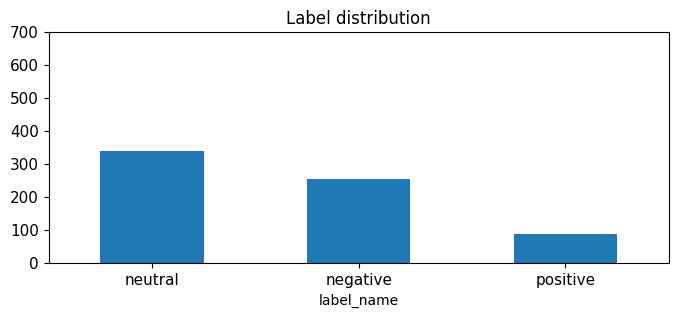

In [113]:
print(train_df.label_name.value_counts())

# plot barchart for X
train_df.label_name.value_counts().plot(kind = 'bar',
                                    title = 'Label distribution',
                                    ylim = [0, 700],        
                                    rot = 0, fontsize = 11, figsize = (8,3))

label_name
neutral     245
negative    190
positive     65
Name: count, dtype: int64


<Axes: title={'center': 'Label distribution'}, xlabel='label_name'>

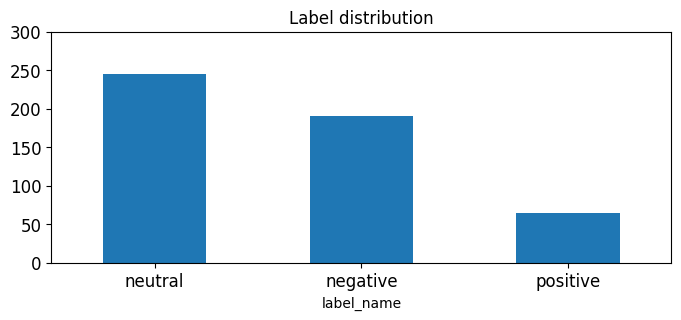

In [115]:
print(train_df_sample.label_name.value_counts())

# plot barchart for X_sample
train_df_sample.label_name.value_counts().plot(kind = 'bar',
                                           title = 'Label distribution',
                                           ylim = [0, 300], 
                                           rot = 0, fontsize = 12, figsize = (8,3))

### >>> **Exercise 7 :**
y軸刻度隨著次數增加調整

<Axes: title={'center': 'Label distribution'}, xlabel='label_name'>

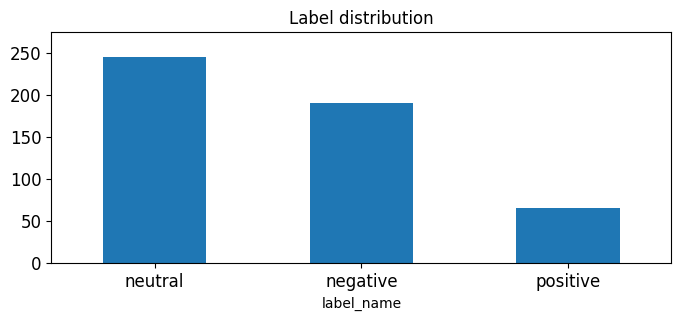

In [116]:
# Answer here
train_df_sample.label_name.value_counts().plot(kind = 'bar',
                                           title = 'Label distribution',
                                           ylim = [0,train_df_sample.label_name.value_counts().max()+30 ], 
                                           rot = 0, fontsize = 12, figsize = (8,3))

### >>> **Exercise 8：**
視覺化抽樣前後資料分布的差異-繪製到同一張圖

            train_df_category_name  train_df_samplecategory_name
label_name                                                      
neutral                        338                           245
negative                       252                           190
positive                        87                            65


<Axes: title={'center': 'Label distribution'}, xlabel='label_name'>

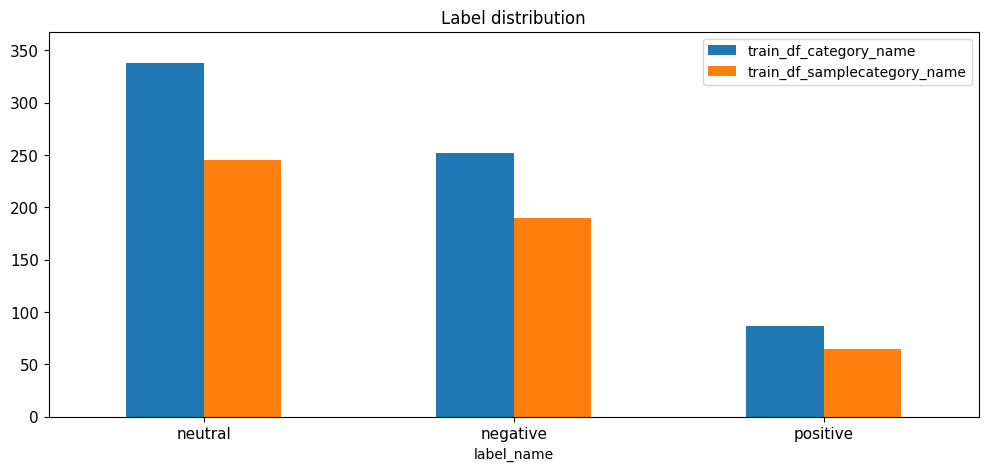

In [117]:
df_plot = pd.DataFrame({
    'train_df_category_name': train_df['label_name'].value_counts(),
    'train_df_samplecategory_name': train_df_sample['label_name'].value_counts()
}).fillna(0).astype(int)
print(df_plot)
df_plot.plot(kind = 'bar',
            title = 'Label distribution',
            ylim = [0,train_df.label_name.value_counts().max()+30 ], 
            rot = 0, fontsize = 11, figsize = (12,5))

### 4.2 Feature Creation


In [118]:
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/kuojouhsiang/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/kuojouhsiang/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [120]:
# takes a like a minute or two to process

train_df['unigrams'] = train_df['text'].apply(lambda x: dmh.tokenize_text(x))

#dmh.tokenize_text:先把文章切成句子，再把句子切成單字

In [121]:
train_df[0:4]["unigrams"]

0                                [Disgusting, tactics]
1                                       [Cope, harder]
2    [#, Stock, winners, *, *, 11.65, %, GameStop, ...
3                 [DOGE, is, going, up, today, 153, %]
Name: unigrams, dtype: object

In [123]:
train_df[0:4]

,text,label,label_name,unigrams
0,Disgusting tactics,0.0,neutral,"[Disgusting, tactics]"
1,Cope harder,-1.0,negative,"[Cope, harder]"
2,# Stock winners\n\n\n\n**11.65% GameStop**\n\n...,0.0,neutral,"[#, Stock, winners, *, *, 11.65, %, GameStop, ..."
3,DOGE is going up today 153%,1.0,positive,"[DOGE, is, going, up, today, 153, %]"


In [124]:
list(train_df[0:1]['unigrams'])

[['Disgusting', 'tactics']]

### 4.3 Feature subset selection


In [126]:
from sklearn.feature_extraction.text import CountVectorizer

count_vect = CountVectorizer()
train_df_counts = count_vect.fit_transform(train_df.text) 
print(train_df_counts[0:10])

  (np.int32(0), np.int32(1051))	1
  (np.int32(0), np.int32(3338))	1
  (np.int32(1), np.int32(841))	1
  (np.int32(1), np.int32(1620))	1
  (np.int32(2), np.int32(3229))	2
  (np.int32(2), np.int32(3759))	1
  (np.int32(2), np.int32(15))	1
  (np.int32(2), np.int32(121))	1
  (np.int32(2), np.int32(1491))	2
  (np.int32(2), np.int32(1134))	2
  (np.int32(2), np.int32(2832))	2
  (np.int32(2), np.int32(1968))	1
  (np.int32(2), np.int32(3722))	1
  (np.int32(2), np.int32(1907))	5
  (np.int32(2), np.int32(1883))	3
  (np.int32(2), np.int32(3675))	2
  (np.int32(2), np.int32(651))	1
  (np.int32(2), np.int32(2935))	1
  (np.int32(2), np.int32(743))	1
  (np.int32(2), np.int32(1991))	1
  (np.int32(2), np.int32(2255))	1
  (np.int32(2), np.int32(3450))	10
  (np.int32(2), np.int32(2881))	1
  (np.int32(2), np.int32(3395))	12
  (np.int32(2), np.int32(3258))	1
  :	:
  (np.int32(9), np.int32(3396))	1
  (np.int32(9), np.int32(1091))	1
  (np.int32(9), np.int32(3510))	2
  (np.int32(9), np.int32(1244))	1
  (np.int32(

In [127]:
count_vect.get_feature_names_out()[1051]

'disgusting'

In [128]:
count_vect.get_feature_names_out()[2832]

'report'

In [129]:
analyze = count_vect.build_analyzer()
analyze("I am craving for a hawaiian pizza right now")

# tokenization, remove stop words (e.g i, a, the), create n-gram (or unigram)

['am', 'craving', 'for', 'hawaiian', 'pizza', 'right', 'now']

### **>>> Exercise 9 :**
turn  text document into a tokenized text using the build_analyzer()

In [130]:
analyze(train_df.text[0])

['disgusting', 'tactics']

In [131]:
analyze(train_df.text[2])

['stock',
 'winners',
 '11',
 '65',
 'gamestop',
 'earnings',
 'report',
 'gamestop',
 'knows',
 'what',
 'its',
 'investors',
 'want',
 'ceo',
 'ryan',
 'cohen',
 'latest',
 'move',
 'to',
 'revive',
 'the',
 'struggling',
 'video',
 'game',
 'retailer',
 'is',
 'putting',
 'its',
 'billion',
 'cash',
 'reserve',
 'into',
 'bitcoin',
 'following',
 'in',
 'microstrategy',
 'footsteps',
 'cnbc',
 '25',
 'nintendo',
 'rumors',
 'are',
 'flying',
 'that',
 'the',
 'video',
 'game',
 'company',
 'could',
 'launch',
 'the',
 'switch',
 'as',
 'soon',
 'as',
 'june',
 'it',
 'the',
 'updated',
 'version',
 'of',
 'its',
 'hugely',
 'successful',
 'switch',
 'console',
 'first',
 'released',
 'in',
 '2017',
 'some',
 'reports',
 'say',
 'full',
 'reveal',
 'could',
 'happen',
 'as',
 'early',
 'as',
 'next',
 'week',
 'and',
 'investors',
 'are',
 'expecting',
 'big',
 'sales',
 'sherwood',
 '08',
 'dollar',
 'tree',
 'earnings',
 'report',
 'the',
 'discount',
 'retail',
 'chain',
 'is',
 '

In [ ]:
# We can check the shape of this matrix by:
train_df_counts.shape

(677, 3837)

In [133]:
# We can obtain the feature names of the vectorizer, i.e., the terms
# usually on the horizontal axis
count_vect.get_feature_names_out()[0:10]

array(['00', '000', '01378', '02', '027', '03', '08', '10', '100', '1000'],
      dtype=object)

In [134]:
# we convert from sparse array to normal array
train_df_counts[0:5, 0:100].toarray()

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0,

In [138]:
count_vect.get_feature_names_out()[6]

'08'

### **>>> Exercise 10 :**
another `1` in the same record


In [139]:
count_vect.get_feature_names_out()[15]

'11'

In [140]:
plot_x = ["term_"+str(i) for i in count_vect.get_feature_names_out()[0:20]]

In [141]:
plot_y = ["doc_"+ str(i) for i in list(train_df.index)[0:20]]

In [142]:
plot_z = train_df_counts[0:20, 0:20].toarray() #X_counts[how many documents, how many terms]

In [143]:
plot_z

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0,

### 4.4Visulization

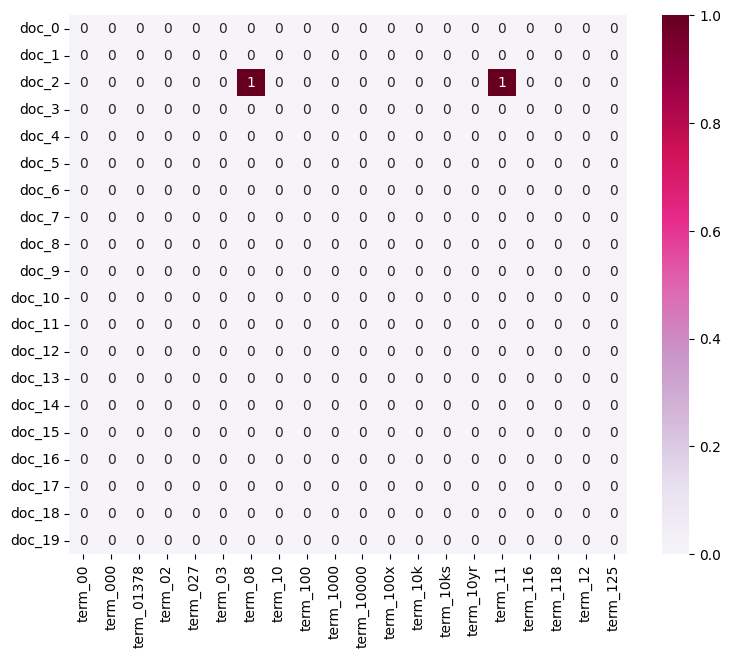

In [144]:
import seaborn as sns

df_todraw = pd.DataFrame(plot_z, columns = plot_x, index = plot_y)
plt.subplots(figsize=(9, 7))
ax = sns.heatmap(df_todraw,
                 cmap="PuRd",
                 vmin=0, vmax=1, annot=True)

### **>>> Exercise 11 :** 
1.改用TFIDF方式反映詞的權重

2.隨機抽樣30*30的樣本

3.熱力圖中格子內的數字代表某個詞在某篇文中的TFIDF權重，0表示該字詞在文章中沒有出現，數字越大代表在文章中越重要

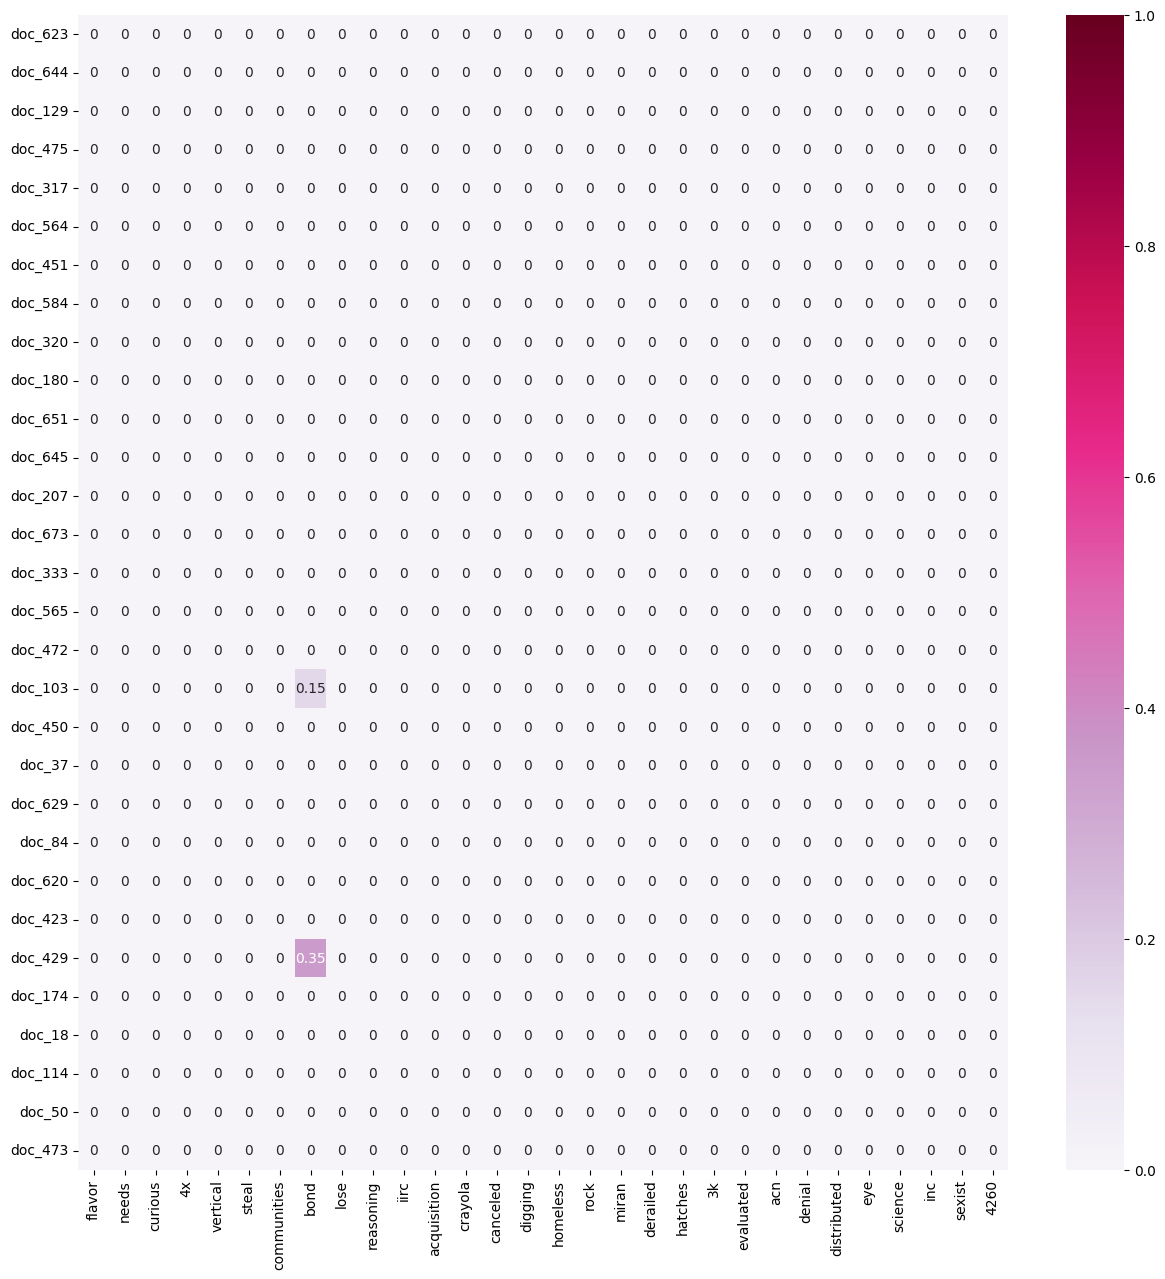

In [145]:
from sklearn.feature_extraction.text import TfidfTransformer

tfidf = TfidfTransformer(norm='l2', use_idf=True, smooth_idf=True)
train_df_tfidf = tfidf.fit_transform(train_df_counts)  
vocab = count_vect.get_feature_names_out()

docs_sample = 30
terms_sample = 30
rows = np.random.choice(train_df_tfidf.shape[0], docs_sample, replace=False)
cols = np.random.choice(train_df_tfidf.shape[1], terms_sample, replace=False)
matrix = train_df_tfidf[rows,:][:,cols].toarray()
doc_labels = [f"doc_{i}" for i in rows]      
term_labels = vocab[cols] 

plot_tfidf = pd.DataFrame(matrix, columns =term_labels, index=doc_labels)
plt.subplots(figsize=(15,15))
ax = sns.heatmap(plot_tfidf,
                 cmap="PuRd",
                 vmin=0, vmax=1,annot=True)

### 4.5 Attribute Transformation / Aggregation
###  4.5.1 Transform Text Data

計算詞頻


In [146]:
term_frequencies = []
for j in range(0,train_df_counts.shape[1]):
    term_frequencies.append(sum(train_df_counts[:,j].toarray()))

In [147]:
term_frequencies = np.asarray(train_df_counts.sum(axis=0))[0]

In [148]:
term_frequencies[0] #sum of first term: 00

np.int64(3)

/var/folders/lx/b868nzys5b9139jlvjxp7r800000gn/T/ipykernel_9455/3480579971.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(count_vect.get_feature_names_out()[:300], rotation = 90);


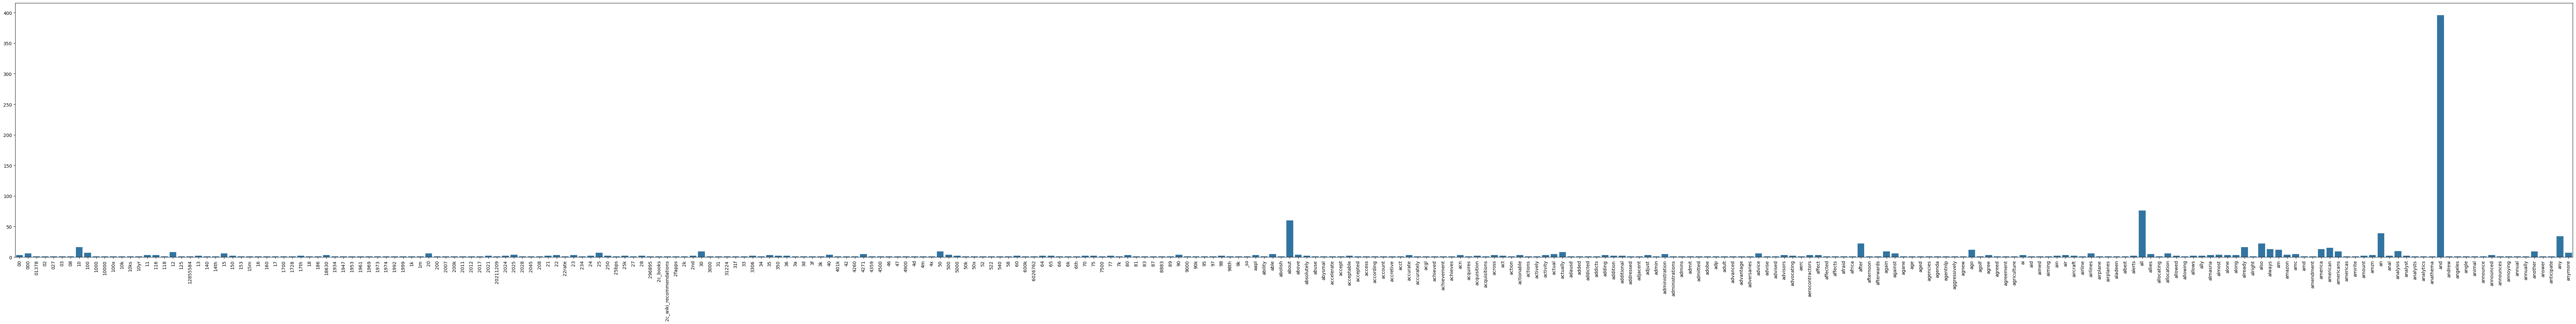

In [149]:
plt.subplots(figsize=(100, 10))
g = sns.barplot(x=count_vect.get_feature_names_out()[:300], 
            y=term_frequencies[:300])
g.set_xticklabels(count_vect.get_feature_names_out()[:300], rotation = 90);

### >>> **Exercise 12 :**
用ploty 繪製圖形

In [150]:
import plotly.express as pe
x_freq = count_vect.get_feature_names_out()[:300]
y_freq = term_frequencies[:300]
df = pd.DataFrame({"term": x_freq, "freq": y_freq})
h = pe.bar(df, x= 'term', y='freq', title="Term frequencies",labels={"term": "Term", "freq": "Frequency"})
h.update_layout(xaxis_tickangle=-90, width=1600, height=500, bargap=0.2)

### >>> **Exercise 13 :** 
efficiently reduce the number of terms

1.過濾常出現或不常出現的單詞

2.計算詞頻後，依詞頻高低排序，取前50個

In [151]:
K = 50
count_vect = CountVectorizer(stop_words='english', max_df=0.5, min_df=5)
train_df_counts = count_vect.fit_transform(train_df.text) 
term_freq = np.asarray(train_df_counts.sum(axis=0)).ravel()   
topk_idex = term_freq.argsort()[::-1][:K]
x_freq   = count_vect.get_feature_names_out()[topk_idex]
y_freq   = term_freq[topk_idex]
df = pd.DataFrame({"term": x_freq, "freq": y_freq})
h = pe.bar(df, x= 'term', y='freq', title="Term frequencies",labels={"term": "Term", "freq": "Frequency"})
h.update_layout(xaxis_tickangle=-90, width=1600, height=500, bargap=0.2)

### >>> **Exercise 14 :** 
長尾分布圖

1.做TFIDF，計算IDF

2.找出平均TFIDF權重前K高個的字詞

3.建一個DF，按照權重大小排序

In [152]:
K = 100
tfidf = TfidfTransformer(norm='l2', use_idf=True, smooth_idf=True)
train_df_tfidf = tfidf.fit_transform(train_df_counts)
mean_tfidf = np.array(train_df_tfidf.mean(axis=0)).ravel()
topk_idex = mean_tfidf.argsort()[::-1][:K]    
vocab = count_vect.get_feature_names_out()
df_topk = pd.DataFrame({
    "term": vocab[topk_idex],
    "score": mean_tfidf[topk_idex]
}).sort_values("score", ascending=False)
k= pe.bar(df_topk, x="term", y="score", orientation="v",
             title=f"Top {K} Terms",
             labels=({"score":"Score","term":"Term"}))
k.update_layout(height=900)

transform the values in that vector into the log distribution

In [162]:
import math
term_frequencies_log = [math.log(i) for i in term_frequencies]

/var/folders/lx/b868nzys5b9139jlvjxp7r800000gn/T/ipykernel_9455/2166548998.py:4: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



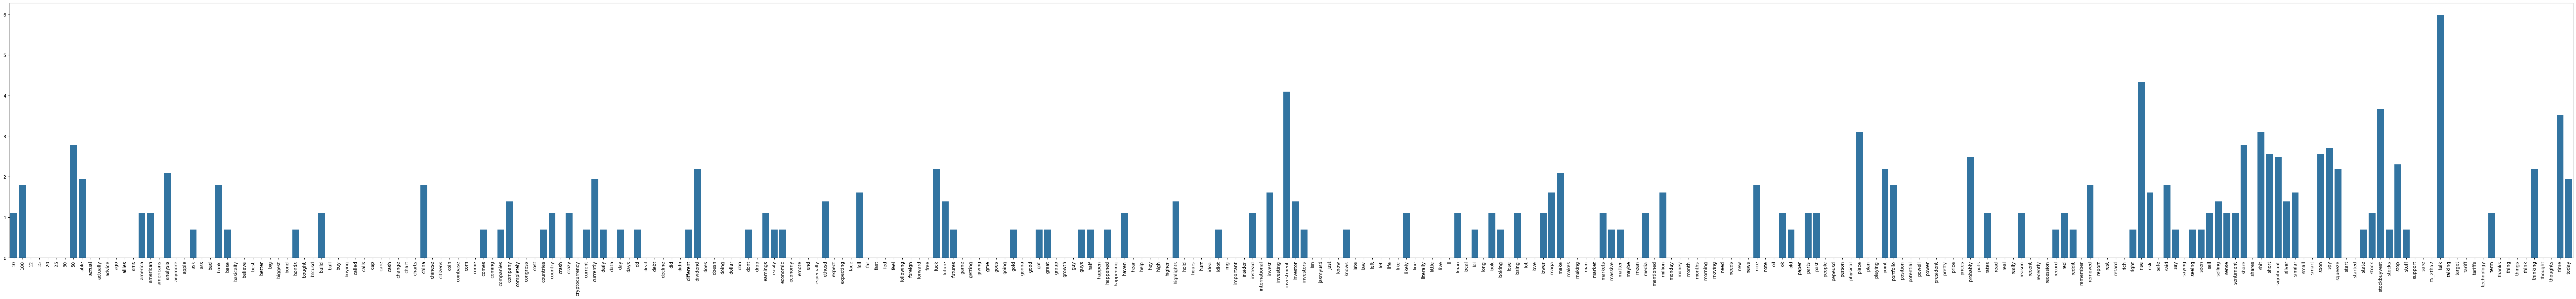

In [154]:
plt.subplots(figsize=(100, 10))
g = sns.barplot(x=count_vect.get_feature_names_out()[:300],
                y=term_frequencies_log[:300])
g.set_xticklabels(count_vect.get_feature_names_out()[:300], rotation = 90);

### >>> **Exercise 15 :** 

Y軸單位從次數改成LOG(次)，LOG的函數性質可以有效改善詞頻分布差異大的問題。

在原始詞頻分布中只有很少數的詞出現頻率很高，大部分的詞只出現少次，導致在原始分布中低頻率的詞幾乎看不出差別。

透過LOG函數轉換可以把高頻率壓縮、小頻率放大，改善長尾效果

In [163]:
import plotly.express as pe
term_frequencies_log = [math.log(i) for i in term_frequencies]
x_freq = count_vect.get_feature_names_out()[:300]
y_freq = term_frequencies_log[:300]
df = pd.DataFrame({"term": x_freq, "freq": y_freq})
df = df.sort_values("freq", ascending=False)
h = pe.bar(df, x= 'term', y='freq', title="Term frequencies",labels={"term": "Term", "freq": "Frequency"})
h.update_layout(xaxis_tickangle=-90, width=1600, height=500, bargap=0.2)

# Phase 2

In [ ]:
### Begin Assignment Here